<a href="https://colab.research.google.com/github/navyadeshmukh/IvLLM-stuff/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [ ]:
import os
import re
import json
import unicodedata
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import MarianTokenizer
from IPython.display import display, HTML
from datasets import load_dataset

from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')



Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Dataset Preprocessing

In [ ]:
print("Loading dataset...")
dataset = load_dataset("Helsinki-NLP/opus_books", "en-it")

Loading dataset...


README.md: 0.00B [00:00, ?B/s]

en-it/train-00000-of-00001.parquet:   0%|          | 0.00/5.73M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/32332 [00:00<?, ? examples/s]

In [ ]:
print("Loading tokenizer...")
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-it')

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"PAD token ID: {tokenizer.pad_token_id}")
print(f"EOS token ID: {tokenizer.eos_token_id}")

Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/789k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/814k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Vocabulary size: 80035
PAD token ID: 80034
EOS token ID: 0


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [ ]:
MAX_LEN = 64
class SimpleTranslationDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_length=MAX_LEN):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        translation = self.dataset[idx]['translation']

        src = self.tokenizer.encode(
            translation['en'],
            max_length=self.max_length,
            truncation=True,
            padding=False
        )

        tgt = self.tokenizer.encode(
            translation['it'],
            max_length=self.max_length,
            truncation=True,
            padding=False
        )

        return {
            'src': torch.tensor(src, dtype=torch.long),
            'tgt': torch.tensor(tgt, dtype=torch.long)
        }

In [ ]:
def collate_fn(batch):
    src_batch = [item['src'] for item in batch]
    tgt_batch = [item['tgt'] for item in batch]

    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=tokenizer.pad_token_id)
    tgt_padded = pad_sequence(tgt_batch, batch_first=True, padding_value=tokenizer.pad_token_id)

    return {'src': src_padded, 'tgt': tgt_padded}


print("Creating datasets...")
full_dataset = SimpleTranslationDataset(dataset['train'], tokenizer, max_length=128)

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=2)

Creating datasets...


In [ ]:
sample = dataset['train'][4]['translation']
en_tokens = tokenizer.encode(sample['en'])
it_tokens = tokenizer.encode(sample['it'])

print(f"\nEnglish: {sample['en']}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(en_tokens)}")
print(f"Token IDs: {en_tokens}")
print(f"\nItalian: {sample['it']}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(it_tokens)}")
print(f"Token IDs: {it_tokens}")


English: There was no possibility of taking a walk that day.
Tokens: ['▁There', '▁was', '▁no', '▁possibility', '▁of', '▁taking', '▁a', '▁walk', '▁that', '▁day', '.', '</s>']
Token IDs: [426, 82, 138, 3946, 8, 1500, 9, 2175, 33, 513, 2, 0]

Italian: I. In quel giorno era impossibile passeggiare.
Tokens: ['▁I', '.', '▁In', '▁que', 'l', '▁', 'giorno', '▁era', '▁imp', 'ossi', 'b', 'ile', '▁pass', 'egg', 'ia', 're', '.', '</s>']
Token IDs: [22, 2, 79, 2716, 179, 16, 5060, 350, 9629, 7124, 156, 2523, 2477, 18778, 385, 51, 2, 0]


In [ ]:
print("\nAnalyzing dataset statistics...")

def analyze_dataset(dataset, tokenizer, num_samples=5000):
    src_lengths, tgt_lengths = [], []

    for i in tqdm(range(min(num_samples, len(dataset)))):
        # 'dataset' here is a torch.utils.data.Subset (e.g., train_dataset or val_dataset)
        # To get the original HuggingFace translation sample:
        # 1. dataset.indices[i] gives the index in the SimpleTranslationDataset.
        # 2. dataset.dataset is the SimpleTranslationDataset instance itself.
        # 3. dataset.dataset.dataset is the original HuggingFace dataset split (e.g., dataset['train']).
        original_idx_in_simple_ds = dataset.indices[i]
        sample = dataset.dataset.dataset[original_idx_in_simple_ds]['translation']

        src_lengths.append(len(tokenizer.encode(sample['en'])))
        tgt_lengths.append(len(tokenizer.encode(sample['it'])))

    return {
        'src_mean': np.mean(src_lengths),
        'src_max': np.max(src_lengths),
        'src_95th': np.percentile(src_lengths, 95),
        'tgt_mean': np.mean(tgt_lengths),
        'tgt_max': np.max(tgt_lengths),
        'tgt_95th': np.percentile(tgt_lengths, 95),
    }

stats = analyze_dataset(train_dataset, tokenizer)

# 8. Print Summary
print("\n" + "="*50)
print("PREPROCESSING COMPLETE")
print("="*50)
print(f"Tokenizer: Helsinki-NLP/opus-mt-en-it")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset):,}")
print(f"  Validation: {len(val_dataset):,}")
print(f"\nToken statistics (first 5000 samples):")
print(f"  EN mean: {stats['src_mean']:.1f}, max: {stats['src_max']}, 95th: {stats['src_95th']:.1f}")
print(f"  IT mean: {stats['tgt_mean']:.1f}, max: {stats['tgt_max']}, 95th: {stats['tgt_95th']:.1f}")


Analyzing dataset statistics...


100%|██████████| 5000/5000 [00:02<00:00, 1949.74it/s]


PREPROCESSING COMPLETE
Tokenizer: Helsinki-NLP/opus-mt-en-it
Vocabulary size: 80035

Dataset sizes:
  Train: 25,865
  Validation: 6,467

Token statistics (first 5000 samples):
  EN mean: 32.8, max: 252, 95th: 85.0
  IT mean: 50.1, max: 431, 95th: 135.0


In [ ]:
# Test a batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Source: {batch['src'].shape}")
print(f"  Target: {batch['tgt'].shape}")

# Save config
# Convert NumPy scalars to standard Python types for JSON serialization
serializable_stats = {
    key: value.item() if isinstance(value, (np.int64, np.float64)) else value
    for key, value in stats.items()
}

config = {
    'vocab_size': tokenizer.vocab_size,
    'max_length': 128,
    'pad_token_id': tokenizer.pad_token_id,
    'stats': serializable_stats, # Use the serializable stats dictionary
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
}

with open('preprocessing_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("\n✓ Config saved to preprocessing_config.json")
print("\nReady to build and train your Transformer model!")


Batch shapes:
  Source: torch.Size([16, 76])
  Target: torch.Size([16, 128])

✓ Config saved to preprocessing_config.json

Ready to build and train your Transformer model!


## Model Definitions


In [ ]:
import torch.nn as nn
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_seq_len=5000, dropout=0.1):

        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix [max_seq_len, d_model]
        pe = torch.zeros(max_seq_len, d_model)

        # Create position indices [0, 1, 2, ..., max_seq_len-1]
        # Shape: [max_seq_len, 1]
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)

        # Create division term for the formula
        # 10000^(2i/d_model) = exp(2i * log(10000) / d_model)
        # Shape: [d_model/2]
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # Apply sin to even indices (0, 2, 4, ...)
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cos to odd indices (1, 3, 5, ...)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension: [1, max_seq_len, d_model]
        pe = pe.unsqueeze(0)

        # Register as buffer (not a parameter, but part of state)
        # Buffers are saved with model but not trained
        self.register_buffer('pe', pe)

    def forward(self, x):
        # extracts [1, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)

    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    # Apply Mask
    '''
    Padding mask: Ignore padding tokens (value = 0 or False)
    Future mask: Prevent looking ahead in decoder (upper triangular = 0)
    '''
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # Apply softmax to get attention weights
    # Shape: [batch, heads, seq_len, seq_len]
    attention_weights = F.softmax(scores, dim=-1)

    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # Apply attention weights to values
    # [batch, heads, seq_len, seq_len] × [batch, heads, seq_len, d_k]
    # = [batch, heads, seq_len, d_k]
    output = torch.matmul(attention_weights, value)

    return output, attention_weights


In [ ]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()

        # Ensure d_model is divisible by num_heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head (512/8 = 64)

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):

        batch_size = query.size(0)

        # Linear projections
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # Split into multiple heads
        # [batch, seq_len, d_model] -> [batch, seq_len, num_heads, d_k] -> [batch, num_heads, seq_len, d_k]
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # output: [batch, num_heads, seq_len, d_k]
        attn_output, attention_weights = scaled_dot_product_attention(
            Q, K, V, mask, self.dropout)

        # Concatenate heads
        # [batch, num_heads, seq_len, d_k] -> [batch, seq_len, num_heads, d_k] -> [batch, seq_len, d_model]
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, -1, self.d_model)

        # Final linear projection
        output = self.W_o(attn_output)        # output: [batch_size, seq_len, d_model]

        return output


In [ ]:
class PositionwiseFeedForward(nn.Module):

    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.dropout(x) # Fixed: Apply dropout to the tensor 'x', not a scalar
        return self.linear2(x)

In [ ]:
class EncoderLayer(nn.Module):

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()

        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

        # Layer normalization (applied after residual connections)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Args:
            x: [batch_size, seq_len, d_model]
            mask: [batch_size, 1, 1, seq_len] (padding mask)

            output: [batch_size, seq_len, d_model]
        """
        # Residual: x + Sublayer(x)
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed-forward with residual connection and layer norm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x


In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # Masked self-attention (on target sequence)
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)

        # Cross-attention (target attends to encoder output)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)

        # Position-wise feed-forward
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        """
        Args:
            x: Target embeddings [batch_size, tgt_len, d_model]
            encoder_output: Encoder output [batch_size, src_len, d_model]
            src_mask: Source padding mask [batch_size, 1, 1, src_len]
            tgt_mask: Target mask [batch_size, 1, tgt_len, tgt_len]
                     (combines padding + future masking)

        Returns:
            output: [batch_size, tgt_len, d_model]
        """
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Q from decoder, K and V from encoder
        attn_output = self.cross_attn(x, encoder_output, encoder_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))

        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))

        return x

In [ ]:
class Transformer(nn.Module):
    """
    Complete Transformer model for sequence-to-sequence tasks.

    Architecture:
    - Source Embedding + Positional Encoding
    - N × Encoder Layers (6 in paper)
    - Target Embedding + Positional Encoding
    - N × Decoder Layers (6 in paper)
    - Linear projection to vocabulary

    Paper: "Attention is All You Need" (Vaswani et al., 2017)
    """

    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_heads=8, num_encoder_layers=6, num_decoder_layers=6,
                 d_ff=2048, max_seq_len=5000, dropout=0.1, pad_idx=0):
        super(Transformer, self).__init__()

        self.d_model = d_model
        self.pad_idx = pad_idx

        # Embedding layers
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=self.pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=self.pad_idx)

        # Positional encoding (shared for source and target)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_len, dropout)

        # Encoder layers (stacked N times)
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_encoder_layers)
        ])

        # Decoder layers (stacked N times)
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_decoder_layers)
        ])

        # Final linear layer (projects to vocabulary)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Initialize parameters
        self._init_parameters()

    def _init_parameters(self):
        """
        Xavier uniform initialization.
        """
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        # Ensure padding token embeddings are zero after initialization
        if self.pad_idx is not None:
            self.src_embedding.weight.data[self.pad_idx].zero_()
            self.tgt_embedding.weight.data[self.pad_idx].zero_()

    def generate_mask(self, src, tgt):

        # Source mask: mask padding tokens
        # (src != self.pad_idx) creates True for real tokens, False for padding
        # Shape: [batch, 1, 1, src_len]
        src_mask = (src != self.pad_idx).unsqueeze(1).unsqueeze(2)

        # Target padding mask
        # Shape: [batch, 1, tgt_len, 1]
        tgt_padding_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(3)

        tgt_len = tgt.size(1)
        nopeak_mask = torch.triu(torch.ones(1, tgt_len, tgt_len), diagonal=1).type(torch.bool)
        nopeak_mask = (~nopeak_mask).bool()  # Invert (lower triangular = True)
        nopeak_mask = nopeak_mask.to(tgt.device)

        # Combine padding mask and future mask
        # Both must be True for attention to be allowed
        tgt_mask = tgt_padding_mask & nopeak_mask

        return src_mask, tgt_mask

    def encode(self, src, src_mask):
        """
        Encode source sequence.

        Args:
            src: Source token IDs [batch_size, src_len]
            src_mask: Source mask [batch_size, 1, 1, src_len]

        Returns:
            encoder_output: [batch_size, src_len, d_model]
        """
        src_embedded = self.src_embedding(src)

        # Scale embeddings (from paper) helps with optimization
        src_embedded = src_embedded * math.sqrt(self.d_model)

        src_embedded = self.positional_encoding(src_embedded)

        # Pass through encoder layers
        encoder_output = src_embedded
        for layer in self.encoder_layers:
            encoder_output = layer(encoder_output, src_mask)

        return encoder_output

    def decode(self, tgt, encoder_output, src_mask, tgt_mask):
        """
        Decode target sequence.

        Args:
            tgt: Target token IDs [batch_size, tgt_len]
            encoder_output: Encoder output [batch_size, src_len, d_model]
            src_mask: Source mask [batch_size, 1, 1, src_len]
            tgt_mask: Target mask [batch_size, 1, tgt_len, tgt_len]

        Returns:
            decoder_output: [batch_size, tgt_len, d_model]
        """
        tgt_embedded = self.tgt_embedding(tgt)
        tgt_embedded = tgt_embedded * math.sqrt(self.d_model)
        tgt_embedded = self.positional_encoding(tgt_embedded)

        # Pass through decoder layers
        decoder_output = tgt_embedded
        for layer in self.decoder_layers:
            decoder_output = layer(decoder_output, encoder_output, src_mask, tgt_mask)

        return decoder_output

    def forward(self, src, tgt):
        """
        Forward pass through the entire Transformer.

        Args:
            src: Source token IDs [batch_size, src_len]
            tgt: Target token IDs [batch_size, tgt_len]

        Returns:
            output: Logits [batch_size, tgt_len, tgt_vocab_size]
        """
        # Generate masks
        src_mask, tgt_mask = self.generate_mask(src, tgt)

        # Encode source
        encoder_output = self.encode(src, src_mask)

        # Decode target
        decoder_output = self.decode(tgt, encoder_output, src_mask, tgt_mask)

        # Project to vocabulary
        # [batch, tgt_len, d_model] -> [batch, tgt_len, tgt_vocab_size]
        output = self.fc_out(decoder_output)

        return output

## Training Pipeline

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import math
import time
import os
import json

In [ ]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, padding_idx, smoothing=0.1):   #padding_idx: Index of padding token (ex: 59513 if vocab size is 59514)
        super(LabelSmoothingLoss, self).__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.vocab_size = vocab_size
        self.true_dist = None

    def forward(self, pred, target):
        """
        Args:
            pred: Predictions [batch_size * seq_len, vocab_size] (logits)
            target: Ground truth [batch_size * seq_len]

        Returns:
            loss: Scalar loss value
        """
        assert pred.size(1) == self.vocab_size
        pred = F.log_softmax(pred, dim=-1) # convert raw-logits to log-probabilities

        true_dist = pred.data.clone()
        true_dist.fill_(self.smoothing / (self.vocab_size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0

        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0 and mask.size(0) > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)

        self.true_dist = true_dist
        return self.criterion(pred, true_dist.clone().detach())


In [ ]:
class NoamLR:
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.current_step = 0

    def step(self):
        self.current_step += 1
        lr = self.get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        self.optimizer.step()

    def get_lr(self):
        step = self.current_step
        if step == 0:
            step = 1

        lr = self.d_model ** (-0.5) * min(
            step ** (-0.5),
            step * self.warmup_steps ** (-1.5)
        )
        return lr

    def zero_grad(self):
        self.optimizer.zero_grad()  # reset gradients


In [ ]:
def train_epoch(model, train_loader, optimizer, criterion, device, epoch):
    model.train()
    total_loss = 0
    total_tokens = 0

    # simple loop (no tqdm)
    for batch_idx, batch in enumerate(train_loader):
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)

        # Prepare target input and output
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad()

        # Forward pass
        output = model(src, tgt_input)

        # Reshape for loss
        output = output.contiguous().view(-1, output.size(-1))
        tgt_output = tgt_output.contiguous().view(-1)

        loss = criterion(output, tgt_output)

        # Count non-padding tokens
        non_pad_mask = (tgt_output != criterion.padding_idx)
        n_tokens = non_pad_mask.sum().item()

        # Normalize loss
        loss = loss / n_tokens

        # Backward
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Optimizer step
        optimizer.step()

        # Track loss
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    return avg_loss

In [ ]:
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in val_loader:
            # Move data to device
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)

            # Prepare target
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            # Forward pass
            output = model(src, tgt_input)

            # Calculate loss
            output = output.contiguous().view(-1, output.size(-1))
            tgt_output = tgt_output.contiguous().view(-1)

            loss = criterion(output, tgt_output)

            # Count non-padding tokens
            non_pad_mask = (tgt_output != criterion.padding_idx)
            n_tokens = non_pad_mask.sum().item()

            loss = loss / n_tokens

            # Track loss
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    return avg_loss

In [ ]:
def save_checkpoint(model, optimizer, epoch, loss, filepath):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.optimizer.state_dict(),
        'optimizer_step': optimizer.current_step,
        'loss': loss,
    }
    torch.save(checkpoint, filepath)
    # print(f"Checkpoint saved: {filepath}")


def load_checkpoint(model, optimizer, filepath, device):

    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    optimizer.current_step = checkpoint['optimizer_step']
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    print(f"✓ Checkpoint loaded: {filepath}")
    print(f"  Resuming from epoch {epoch}, loss {loss:.4f}")

    return epoch, loss


## Training Loop

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs,
    d_model,
    vocab_size,
    pad_idx,
    device,
    save_dir='/kaggle/input/checkpoints',
    warmup_steps=20,
    label_smoothing=0.1,
    early_stopping_patience=5
):
     # Create save directory
    os.makedirs(save_dir, exist_ok=True)

    # Setup optimizer
    optimizer_base = optim.Adam(
        model.parameters(),
        lr=0,  # Will be set by scheduler
        betas=(0.9, 0.98),
        eps=1e-9
    )
    optimizer = NoamLR(optimizer_base, d_model, warmup_steps)

    # Setup loss function
    criterion = LabelSmoothingLoss(vocab_size, pad_idx, label_smoothing)

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'learning_rates': []
    }

    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0

    print("="*70)
    print("TRAINING CONFIGURATION")
    print("="*70)
    print(f"Device: {device}")
    print(f"Epochs: {num_epochs}")
    print(f"Warmup steps: {warmup_steps}")
    print(f"Label smoothing: {label_smoothing}")
    print(f"Early stopping patience: {early_stopping_patience}")
    print(f"Save directory: {save_dir}")
    print("="*70)


In [ ]:
checkpoint_path = '/kaggle/working/checkpoints/best_model.pt'

def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs,
    d_model,
    vocab_size,
    pad_idx,
    device,
    save_dir='/kaggle/working/checkpoints',
    warmup_steps=4000,
    label_smoothing=0.1,
    early_stopping_patience=5
    ):
    os.makedirs(save_dir, exist_ok=True)

    optimizer_base = optim.Adam(
        model.parameters(),
        lr=0,
        betas=(0.9, 0.98),
        eps=1e-9
    )
    optimizer = NoamLR(optimizer_base, d_model, warmup_steps)
    criterion = LabelSmoothingLoss(vocab_size, pad_idx, label_smoothing)

    history = {
        'train_loss': [],
        'val_loss': [],
        'learning_rates': []
    }

    best_val_loss = float('inf')
    patience_counter = 0

    print("=" * 70)
    print("TRAINING CONFIGURATION")
    print("=" * 70)
    print(f"Device                  : {device}")
    print(f"Epochs                  : {num_epochs}")
    print(f"Warmup steps            : {warmup_steps}")
    print(f"Label smoothing         : {label_smoothing}")
    print(f"Early stopping patience : {early_stopping_patience}")
    print(f"Save directory          : {save_dir}")
    print("=" * 70)

    # 1. Define the path we want to check for resumes BEFORE the 'if' statement
    checkpoint_path = os.path.join(save_dir, 'latest_checkpoint.pt')

    # 2. Now the check will work
    if os.path.exists(checkpoint_path):
        start_epoch, last_loss = load_checkpoint(model, optimizer, checkpoint_path, DEVICE)
        # Update the range to start from the next epoch
        epoch_range = range(start_epoch + 1, num_epochs + 1)
    else:
        print("No checkpoint found, starting from scratch.")
        epoch_range = range(1, num_epochs + 1)

    for epoch in range(1, num_epochs + 1):

        train_loss = train_epoch(model, train_loader, optimizer, criterion, device, epoch)
        val_loss   = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['learning_rates'].append(optimizer.get_lr())

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
        )

        checkpoint_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch}.pt')
        # save_checkpoint(model, optimizer, epoch, val_loss, checkpoint_path)

        if val_loss < best_val_loss:
            best_val_loss   = val_loss
            patience_counter = 0
            best_model_path = os.path.join(save_dir, 'best_model.pt')
            # save_checkpoint(model, optimizer, epoch, val_loss, best_model_path)
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{early_stopping_patience}")

        if patience_counter >= early_stopping_patience:
            print(f"\n{'=' * 70}")
            print(f"Early stopping triggered after {epoch} epochs")
            print(f"Best validation loss: {best_val_loss:.4f}")
            print(f"{'=' * 70}")

        history_path = os.path.join(save_dir, 'training_history.json')
        with open(history_path, 'w') as f:
            json.dump(history, f, indent=2)
             break

    print(f"\n{'=' * 70}")
    print("TRAINING COMPLETE")
    print(f"{'=' * 70}")
    print(f"Total epochs       : {epoch}")
    print(f"Best val loss      : {best_val_loss:.4f}")
    print(f"Checkpoints saved  : {save_dir}")
    print(f"{'=' * 70}\n")

    return history


In [ ]:
def translate_sentence(model, sentence, tokenizer_src, tokenizer_tgt, device="cuda", max_len=100):
    model.eval()

    # 1. Tokenize source sentence
    # Ensure add_special_tokens=True to include the EOS token for the encoder
    src_tokens = tokenizer_src.encode(sentence, add_special_tokens=True)
    src_tensor = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(device)

    # 2. Start token
    # Marian models use pad_token_id as the starting token for the decoder
    start_token = tokenizer_tgt.pad_token_id
    if start_token is None:
        # Fallback to EOS if PAD is somehow missing, though rare for this model
        start_token = tokenizer_tgt.eos_token_id

    tgt_tokens = [start_token]

    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens, dtype=torch.long).unsqueeze(0).to(device)

        # 3. Forward pass
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor)

        # 4. Get next token (greedy decoding)
        # Take the last token from the sequence output
        next_token = output[:, -1, :].argmax(dim=-1).item()
        tgt_tokens.append(next_token)

        # 5. Stop if EOS token is generated
        if next_token == tokenizer_tgt.eos_token_id:
            break

    # 6. Decode tokens → text
    translated = tokenizer_tgt.decode(tgt_tokens, skip_special_tokens=True)
    return translated

In [ ]:

CONFIG_PATH = '/kaggle/working/preprocessing_config.json'
SAVE_DIR = '/kaggle/working/checkpoints'

import torch.nn.functional as F

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

VOCAB_SIZE  = cfg['vocab_size']      # 80035
PAD_IDX     = cfg['pad_token_id']    # 80034
MAX_LENGTH  = cfg['max_length']      # 128

os.makedirs(SAVE_DIR, exist_ok=True)

model = Transformer(
    src_vocab_size    = VOCAB_SIZE,
    tgt_vocab_size     = VOCAB_SIZE,
    d_model            = 256,
    num_heads          = 4,
    num_encoder_layers = 4,
    num_decoder_layers = 4,
    d_ff               = 1024,
    max_seq_len        = MAX_LENGTH,
    dropout            = 0.1,
    pad_idx            = PAD_IDX
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters : {total_params:,}')
print(f'Model size : ~{total_params * 4 / 1024**2:.1f} MB')

Parameters : 68,919,715
Model size : ~262.9 MB


In [ ]:
sentence = "I love learning deep learning"

translation = translate_sentence(
    model,
    sentence,
    tokenizer,
    tokenizer,
    device = "cuda"
)

print("Input :", sentence)
print("Output:", translation)

Input : I love learning deep learning
Output: PrePrePrePre 2016/12 2016/12 2016/12 2016/12 2016/12 2016/12 2016/12 2016/12PrePrePrePrePrePrePre 2016/12 2016/12PrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePre cruise cruise cruise cruise cruise cruise cruisePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePrePre adattati adattati adattati cruise cruise cruise cruise cruise cruise cruise cruise cruise cruisePrePrePrePrePrePrePre


In [ ]:
history = train_model(
    model                   = model,
    train_loader            = train_loader,
    val_loader              = val_loader,
    num_epochs              = 50,
    d_model                 = 256,
    vocab_size              = VOCAB_SIZE,
    pad_idx                 = PAD_IDX,
    device                  = DEVICE,
    save_dir                = SAVE_DIR,
    warmup_steps            = 4000,
    label_smoothing         = 0.1,
    early_stopping_patience = 20
)

TRAINING CONFIGURATION
Device                  : cuda
Epochs                  : 50
Warmup steps            : 4000
Label smoothing         : 0.1
Early stopping patience : 20
Save directory          : /kaggle/working/checkpoints
No checkpoint found, starting from scratch.
Epoch 1/50 | Train Loss: 5.3049 | Val Loss: 3.7424 | 
Epoch 2/50 | Train Loss: 3.4532 | Val Loss: 3.1541 | 
Epoch 3/50 | Train Loss: 3.1015 | Val Loss: 2.9389 | 
Epoch 4/50 | Train Loss: 2.9148 | Val Loss: 2.8525 | 
Epoch 5/50 | Train Loss: 2.8057 | Val Loss: 2.7792 | 
Epoch 6/50 | Train Loss: 2.7314 | Val Loss: 2.7363 | 
Epoch 7/50 | Train Loss: 2.6724 | Val Loss: 2.7083 | 
Epoch 8/50 | Train Loss: 2.6344 | Val Loss: 2.7344 | 
Epoch 9/50 | Train Loss: 2.5962 | Val Loss: 2.7108 | 
Epoch 10/50 | Train Loss: 2.5648 | Val Loss: 2.7014 | 
Epoch 11/50 | Train Loss: 2.5338 | Val Loss: 2.7016 | 
Epoch 12/50 | Train Loss: 2.5047 | Val Loss: 2.7374 | 
Epoch 13/50 | Train Loss: 2.4783 | Val Loss: 2.7207 | 
Epoch 14/50 | Train Los

## Evaluating Model

In [ ]:
# Install the package if you haven't yet
!pip install torchinfo -q

from torchinfo import summary

# 1. Prepare dummy data matching your batch format
# Using batch size 16, and lengths from your config
batch_size = 16
dummy_src = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH)).to(DEVICE)
dummy_tgt_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH - 1)).to(DEVICE)

# 2. Print the summary
# Note: input_data must be a tuple of (arg1, arg2, ...)
summary(
    model,
    input_data=(dummy_src, dummy_tgt_input),
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
    depth=3,
    device=DEVICE
)

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Mult-Adds
Transformer                                   [16, 128]                 [16, 127, 80035]          --                        --
├─Embedding: 1-1                              [16, 128]                 [16, 128, 256]            20,488,960                327,823,360
├─PositionalEncoding: 1-2                     [16, 128, 256]            [16, 128, 256]            --                        --
│    └─Dropout: 2-1                           [16, 128, 256]            [16, 128, 256]            --                        --
├─ModuleList: 1-3                             --                        --                        --                        --
│    └─EncoderLayer: 2-2                      [16, 128, 256]            [16, 128, 256]            --                        --
│    │    └─MultiHeadAttention: 3-1           [16, 128, 256]            [16, 128, 256]         

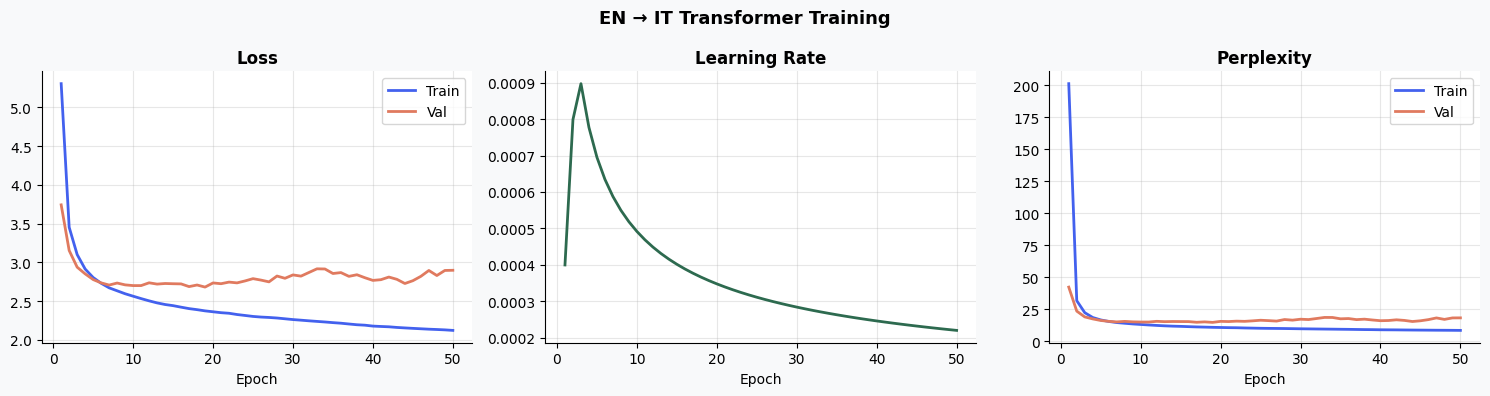

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#f8f9fa')

ax = axes[0]
ax.plot(epochs, history['train_loss'], color='#4361ee', lw=2, label='Train')
ax.plot(epochs, history['val_loss'],   color='#e07a5f', lw=2, label='Val')
ax.set_title('Loss',          fontweight='bold'); ax.set_xlabel('Epoch'); ax.legend()
ax.spines[['top','right']].set_visible(False);    ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs, history['learning_rates'], color='#2d6a4f', lw=2)
ax.set_title('Learning Rate', fontweight='bold'); ax.set_xlabel('Epoch')
ax.spines[['top','right']].set_visible(False);    ax.grid(alpha=0.3)

# Perplexity = exp(loss)
ax = axes[2]
ax.plot(epochs, [math.exp(l) for l in history['train_loss']], color='#4361ee', lw=2, label='Train')
ax.plot(epochs, [math.exp(l) for l in history['val_loss']],   color='#e07a5f', lw=2, label='Val')
ax.set_title('Perplexity',    fontweight='bold'); ax.set_xlabel('Epoch'); ax.legend()
ax.spines[['top','right']].set_visible(False);    ax.grid(alpha=0.3)

plt.suptitle('EN → IT Transformer Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def compute_bleu(references, hypotheses, max_n=4):
    """
    Args:
    references: List of reference translations (strings)
    hypotheses: List of model translations (strings)
    max_n: Maximum n-gram order (4 for BLEU-4)

    Returns:
        bleu_score: BLEU score (0 to 100)
    """
    try:
        from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
        from nltk.tokenize import word_tokenize
    except ImportError:
        print("Please install nltk: pip install nltk")
        return None

    # Tokenize
    references_tok = [[word_tokenize(ref.lower())] for ref in references]
    hypotheses_tok = [word_tokenize(hyp.lower()) for hyp in hypotheses]

    # Compute BLEU with smoothing
    smoothing = SmoothingFunction().method1
    bleu = corpus_bleu(
        references_tok,
        hypotheses_tok,
        smoothing_function=smoothing,
        weights=[1/max_n] * max_n
    )

    return bleu * 100  # Convert to percentage


In [ ]:
def evaluate_model(model, val_loader, tokenizer, device, num_samples=None):

    model.eval()

    references = []
    hypotheses = []
    examples = []

    count = 0
    for batch in val_loader:
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)

        batch_size = src.size(0)

        for i in range(batch_size):
            # Get source and reference
            src_tokens = src[i:i+1]
            tgt_tokens = tgt[i]

            src_text = tokenizer.decode(src_tokens[0].cpu().numpy(), skip_special_tokens=True)
            ref_text = tokenizer.decode(tgt_tokens.cpu().numpy(), skip_special_tokens=True)

            # Translate
            src_mask = (src_tokens != tokenizer.pad_token_id).unsqueeze(1).unsqueeze(2)

            output_tokens = greedy_decode(
                model=model,
                src=src_tokens,
                src_mask=src_mask,
                max_len=128,
                start_symbol=tokenizer.bos_token_id or tokenizer.eos_token_id,
                end_symbol=tokenizer.eos_token_id,
                device=device
            )

            hyp_text = tokenizer.decode(output_tokens[0].cpu().numpy(), skip_special_tokens=True)

            references.append(ref_text)
            hypotheses.append(hyp_text)

            # Save first few examples
            if len(examples) < 10:
                examples.append((src_text, ref_text, hyp_text))

            count += 1
            if num_samples and count >= num_samples:
                break

        if num_samples and count >= num_samples:
            break

    # Compute BLEU
    bleu = compute_bleu(references, hypotheses)

    return bleu, examples



In [ ]:
def interactive_translate(model, tokenizer, device):
    """
    Interactive translation loop.

    Type sentences to translate, 'quit' to exit.
    """
    print("="*70)
    print("INTERACTIVE TRANSLATION (English → Italian)")
    print("="*70)
    print("Type a sentence to translate, or 'quit' to exit.")
    print()

    while True:
        # Get input
        sentence = input("English: ").strip()

        if sentence.lower() in ['quit', 'exit', 'q']:
            print("Goodbye!")
            break

        if not sentence:
            continue

        # Translate
        try:
            translation = translate_sentence(
                model=model,
                sentence=sentence,
                tokenizer=tokenizer,
                device=device,
                method='beam',
                beam_width=5
            )
            print(f"Italian:  {translation}\n")
        except Exception as e:
            print(f"Error: {e}\n")


In [ ]:
!pip install evaluate sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.9 MB/s eta 0:00:00


In [ ]:
import evaluate # Make sure you have !pip install evaluate sacrebleu
metric = evaluate.load("sacrebleu")

def evaluate_bleu(model, dataloader, tokenizer, device, num_samples=100):
    model.eval()
    predictions = []
    references = []

    # Take a subset of validation for speed
    for i, batch in enumerate(dataloader):
        if i >= num_samples // dataloader.batch_size: break

        src = batch['src'].to(device)
        # Use your existing translate_sentence or a batch version
        for j in range(src.size(0)):
            # Decode the original English sentence from IDs back to text for translation
            eng_text = tokenizer.decode(src[j], skip_special_tokens=True)
            # NEW (Correct mapping for Cell [36])
            pred = translate_sentence(model, eng_text, tokenizer, device, method='greedy')

            # Decode reference Italian
            ref = tokenizer.decode(batch['tgt'][j], skip_special_tokens=True)

            predictions.append(pred)
            references.append([ref]) # sacrebleu expects a list of lists

    results = metric.compute(predictions=predictions, references=references)
    return results['score']

# Run it
bleu_score = evaluate_bleu(model, val_loader, tokenizer, DEVICE)
print(f"Validation BLEU Score: {bleu_score:.2f}")

Validation BLEU Score: 0.04


In [ ]:
test_sentences = [
  "Hello, My name is colab"
]

print("-" * 30)
for sent in test_sentences:
    # Remove the extra 'tokenizer' argument
    trans = translate_sentence(model, sent, tokenizer, device=DEVICE, method='greedy')
    print(f"EN: {sent}")
    print(f"IT (Pred): {trans}")
    print("-" * 30)

------------------------------
EN: Hello, My name is colab
IT (Pred): tomi insieme.
------------------------------


In [ ]:
# --- Run evaluate_model (BLEU and Examples) ---
print("Running Batch Evaluation...")
bleu_score, examples = evaluate_model(model, val_loader, tokenizer, DEVICE, num_samples=50)

print(f"\nBatch BLEU Score: {bleu_score:.2f}")
print("\nSample Translations:-")
for i, (src, ref, hyp) in enumerate(examples[:3]):
    print(f"Sample {i+1}:")
    print(f"  EN (Source): {src}")
    print(f"  IT (Target): {ref}")
    print(f"  IT (Pred)  : {hyp}\n")

# --- Run translate_sentence (Manual Test) ---
print("--- Manual Inference Test ---")
test_sent = "There was no possibility of taking a walk that day."
# Using greedy method first to check consistency
translation = translate_sentence(model, test_sent, tokenizer, DEVICE, method='greedy')

print(f"Input : {test_sent}")
print(f"Output: {translation}")

Running Batch Evaluation...

Batch BLEU Score: 0.04

--- Sample Translations ---
Sample 1:
  EN (Source): She is a splendid woman.
  IT (Target): È una carissima donna.
  IT (Pred)  : tomi.

Sample 2:
  EN (Source): We feel so helpless and so little in the great stillness, when the dark trees rustle in the night-wind.
  IT (Target): Ci sentiamo così soli e così piccini nella gran calma, quando gli alberi bui stormiscono al vento notturno.
  IT (Pred)  : tomi allora, egli si mise a ridere.

Sample 3:
  EN (Source): If he had never heard people talk of love, he would never have wanted that word.
  IT (Target): Se non avesse sentito dire che esiste lamore, non avrebbe neanche mai usato questa parola.
  IT (Pred)  : tomi allora, egli si mise a ridere.

--- Manual Inference Test ---
Input : There was no possibility of taking a walk that day.
Output: tomi insieme.
